In [ ]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,f1_score
from sklearn.model_selection import GridSearchCV

In [2]:
df=pd.read_csv("IMDB Dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [3]:
x=df['review']
y=df['sentiment']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4,random_state=0)

In [4]:
tfid=TfidfVectorizer(max_features=5000)
x_train=tfid.fit_transform(x_train)
x_test=tfid.transform(x_test)
np.unique(x_train.data)

array([0.00316629, 0.00339801, 0.00347227, ..., 0.87313296, 0.90977381,
       0.91226527], shape=(3459385,))

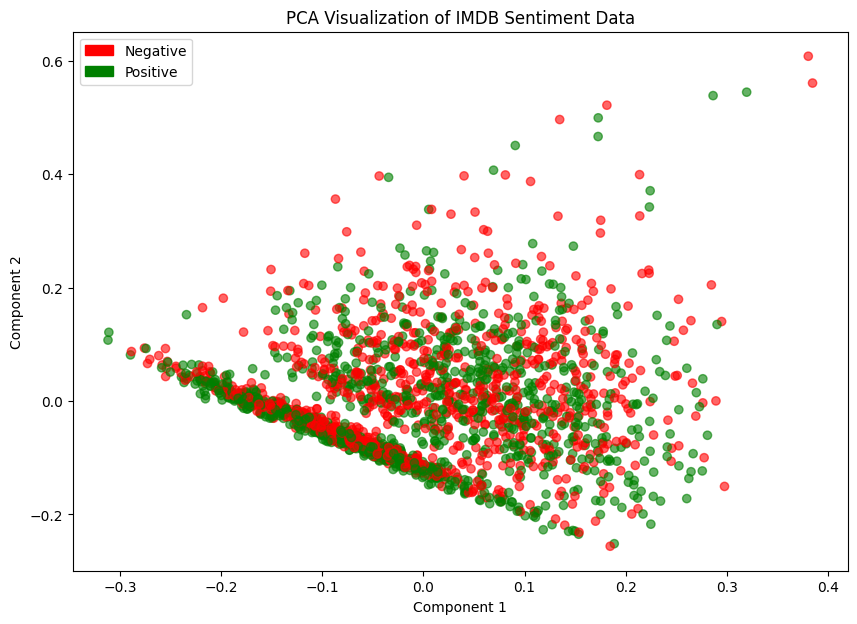

In [5]:
sample_size = 2000
x_sample = x_train[:sample_size]
y_sample = y_train.iloc[:sample_size]
x_sample = x_sample.toarray()
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_sample)
colors = ['red' if label == 'negative' else 'green' for label in y_sample]
plt.figure(figsize=(10,7))
plt.scatter(x_pca[:,0], x_pca[:,1], c=colors, alpha=0.6)
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Negative')
green_patch = mpatches.Patch(color='green', label='Positive')
plt.legend(handles=[red_patch, green_patch])
plt.title("PCA Visualization of IMDB Sentiment Data")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [6]:
model=LinearSVC()
param={'C': [0.01, 0.1, 1, 10]}
optimal_params=GridSearchCV(model,param,cv=3,scoring='f1')
optimal_params.fit(x_train,y_train)

C:\Users\bhuwa\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\bhuwa\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "C:\Users\bhuwa\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bhuwa\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_scorer.py", line 380, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "C:\Users\bhuwa\AppData\Roa

GridSearchCV(cv=3, estimator=LinearSVC(), param_grid={'C': [0.01, 0.1, 1, 10]},
             scoring='f1')

In [7]:
optimal_params.best_estimator_

LinearSVC(C=0.01)

In [8]:
optimal_model=LinearSVC(C=0.01)
optimal_model.fit(x_train,y_train)


LinearSVC(C=0.01)

In [11]:
y_pred=optimal_model.predict(x_test)

In [13]:
f1_score(y_test,y_pred,average='binary',pos_label='positive')

0.8600039269585706

In [16]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    negative       0.88      0.83      0.85     10068
    positive       0.84      0.88      0.86      9932

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000

